# **EDA - meteorología del Atlántico**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import geopandas as gpd
from scipy import stats
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Point
from shapely.geometry import Polygon
import geopandas as gpd

In [2]:
df = pd.read_csv("Mapas/clima_atlantico.csv", encoding='utf-8', low_memory=False)
df['FECHA'] = pd.to_datetime(df['FECHA'], dayfirst=False)
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

## Estaciones

> Para el registro de variables climáticas se recopilaron los datos de 15 estaciones meteorológicas, distribuidas a lo largo del departamento del Atlántico, en el periodo del 31 de diciembre del al primero de enero de 2024. En total se tienen 14,417 registros de la humedad relativa (máxima - mínima), temperatura (máxima - mínima) y la precipitación.

C:\Users\Hp\AppData\Local\Temp\ipykernel_7648\3577674469.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  #


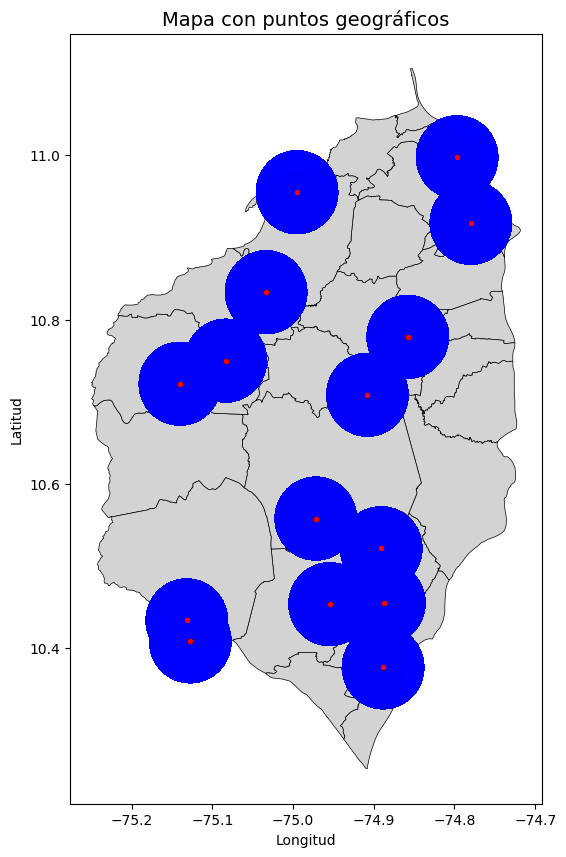

In [3]:
# [Mapa] Distribución de estaciones
df['geometry'] = [Point(xy) for xy in zip(df['LONGITUD'], df['LATITUD'])]
gdf_puntos = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  # CRS geográfico estándar
gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  #

gdf = gdf.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
gdf_puntos['zona'].plot(ax=ax, color='blue', alpha=0.2, edgecolor='blue')  # Círculos
gdf_puntos.plot(ax=ax, color='red', markersize=5, alpha=0.6)

ax.set_title('Mapa con puntos geográficos', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.show()

## Clima

### Humedad

In [4]:
print('Humedad relativa \n____________________')
print(df['HUM RELATIVA_MIN'].describe(), '\n____________________')
print(df['HUM RELATIVA_MAX'].describe())

Humedad relativa 
____________________
count    2418.000000
mean       67.723739
std         8.706435
min        35.000000
25%        63.000000
50%        67.000000
75%        72.000000
max        98.000000
Name: HUM RELATIVA_MIN, dtype: float64 
____________________
count    2418.000000
mean       96.211332
std         2.165190
min        87.000000
25%        95.000000
50%        97.000000
75%        98.000000
max       100.000000
Name: HUM RELATIVA_MAX, dtype: float64


Text(0.5, 1.0, 'Humedad')

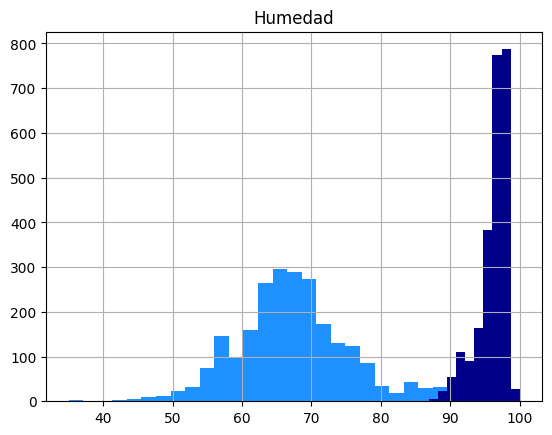

In [5]:
df['HUM RELATIVA_MIN'].hist(color='dodgerblue',bins=30)
df['HUM RELATIVA_MAX'].hist(color='darkblue')
plt.title("Humedad")

La humedad en el Atlántico es variable, de acuerdo a los 2418 registros que miden esta variable, la humedad relativa mínima oscila en un rango amplio del 35% de condiciones muy secas al 98% de condiciones extremadamente húmedas, con una media del 67.7% (~8.7) lo que sugiere que el ambiente tiene una humedad considerable. Para la humedad relativa máxima, la distribución es menos variables, los registros más altos van del 85% al 100%, indicando que el ambiente tiene humedad extrema, especialmente por el sesgo del 25% de los casos que tiene por lo menos una humedad máxima registrada del 98%.

### Temperatura

In [6]:
print('Temperatura \n____________________')
print(df['TEMPERATURA_MIN'].describe(), '\n____________________')
print(df['TEMPERATURA_MAX'].describe())

Temperatura 
____________________
count    4520.000000
mean       23.922102
std         1.150501
min        18.400000
25%        23.400000
50%        24.000000
75%        24.800000
max        27.000000
Name: TEMPERATURA_MIN, dtype: float64 
____________________
count    3677.000000
mean       33.738863
std         1.433534
min        26.400000
25%        33.000000
50%        34.000000
75%        34.600000
max        39.000000
Name: TEMPERATURA_MAX, dtype: float64


Text(0.5, 1.0, 'Temperatura')

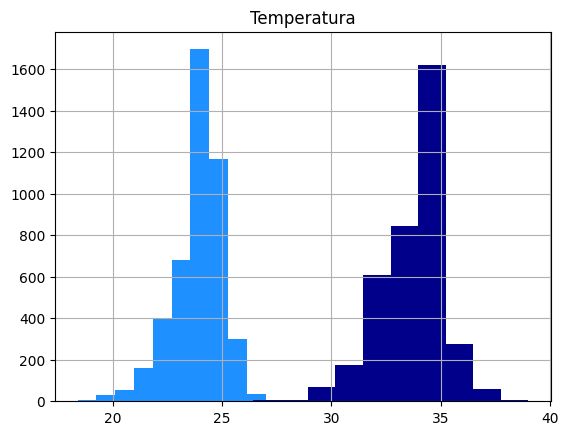

In [7]:
df['TEMPERATURA_MIN'].hist(color='dodgerblue')
df['TEMPERATURA_MAX'].hist(color='darkblue')
plt.title("Temperatura")

La temperatura en el Atlántico es diferenciable a grandes rasgos, mientas que los registros más bajos varian entre los 18.4° y 27°, los más altos varían entre los 26° hasta los 39°, indicando que no en todo el territorio se manejan la misma temperatura y lo variable que puede ser. En promedio la temperatura es de 23.9° para los valores más bajos y de 33.7° para los más grados.

### Precipitación

In [8]:
df['PRECIPITACION_Convencional'].describe()

count    12411.000000
mean         9.240956
std         16.039534
min          0.000000
25%          0.000000
50%          1.600000
75%         12.000000
max        140.000000
Name: PRECIPITACION_Convencional, dtype: float64

<Axes: >

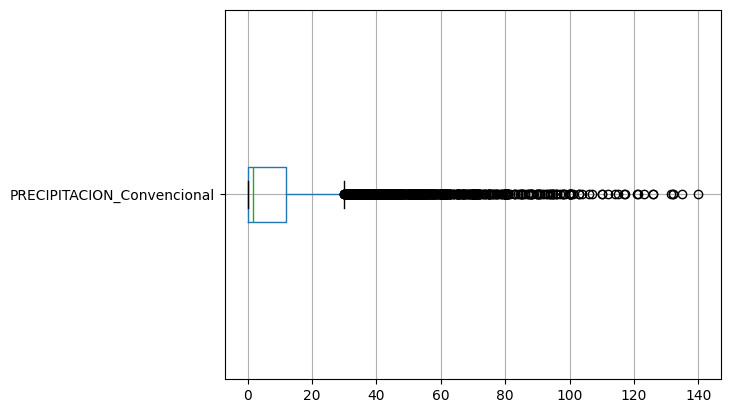

In [9]:
df.boxplot(column='PRECIPITACION_Convencional', vert=False)



La precipitación en el Atlántico es sesgada hacia la derecha, es decir que son más los registros sin precipitación o volúmenes muy bajos. Solo el 25% está por arriba de los 12 m^3.